=== TDAN Inline Summary ===
Rows=15,064  Cols=26  Unique Cells=74  Windows=10,178
T=50  F=10  H=64
SoH: MAE=0.007 | R2=0.998
RUL: MAE=7.601 | R2=0.998


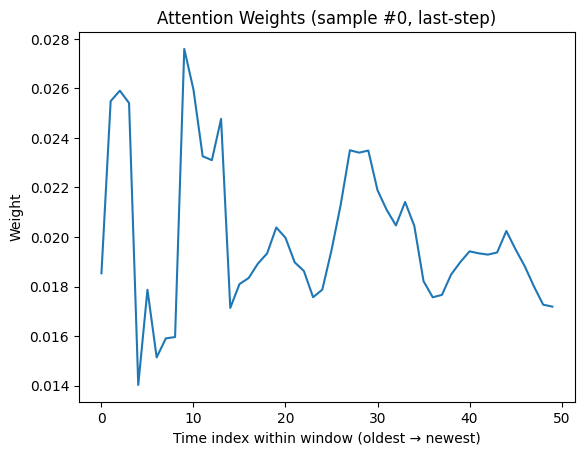

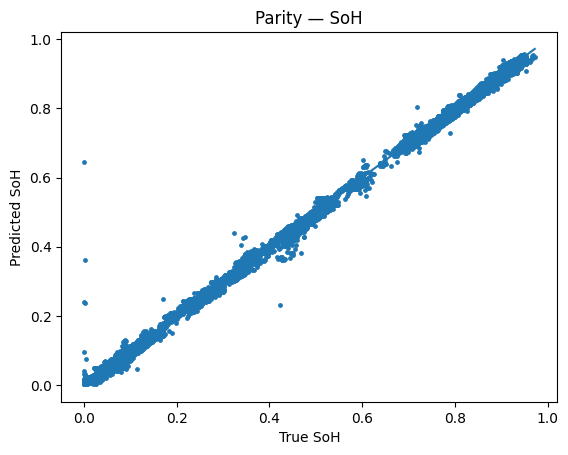

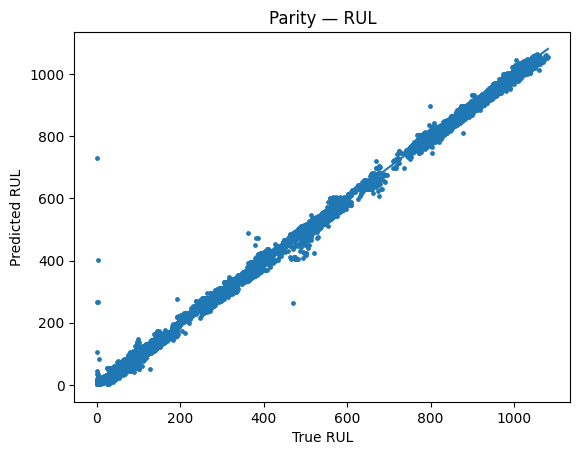


🔹 SoH Performance
   MAE        : 0.007
   R² Score   : 0.998
   ±5% Acc %  : 83.79
   ±10% Acc % : 91.33

🔹 RUL Performance
   MAE        : 7.601
   R² Score   : 0.998
   ±5% Acc %  : 83.79
   ±10% Acc % : 91.33

=== Summary Table ===


,MAE,R2,Acc@5%,Acc@10%
SoH,0.006834,0.998044,83.788564,91.33425
RUL,7.600751,0.998030,83.788564,91.33425


In [5]:
import numpy as np, pandas as pd, math
import torch, torch.nn as nn
from sklearn.model_selection import GroupKFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# ======================
# Config (tweak here)
# ======================
T = 50          # window length (history length per sample)
H = 64          # attention hidden size
N_SPLITS = 5    # GroupKFold(CELL_ID)
N_TREES = 250   # RF trees (speed/accuracy tradeoff)
# To speed up on huge files, limit early cycles used for stitching & training:
LIMIT_CYCLES_MAX = None   # e.g., 300  (None = use all)

# ======================
# 1) Load CSV
# ======================
df_raw = pd.read_csv("../DATA/Battery_RUL_with_features_new.csv")
assert "Cycle_Index" in df_raw.columns, "CSV must have 'Cycle_Index'."
if LIMIT_CYCLES_MAX is not None:
    df_raw = df_raw[df_raw["Cycle_Index"] <= LIMIT_CYCLES_MAX].copy()

# ======================
# 2) Cell_ID stitching (Hungarian; SciPy if available, else fast greedy)
# ======================
try:
    from scipy.optimize import linear_sum_assignment
    SCIPY_AVAILABLE = True
except Exception:
    SCIPY_AVAILABLE = False

def _hungarian_fallback(cost):
    n_rows, n_cols = cost.shape
    assigned_cols = set()
    row_to_col = [-1]*n_rows
    for i in range(n_rows):
        order = np.argsort(cost[i])
        for j in order:
            if j not in assigned_cols:
                row_to_col[i] = j
                assigned_cols.add(j)
                break
    return np.arange(n_rows), np.array(row_to_col)

def _build_cost(A, B, cap=10.0, soh_a=None, soh_b=None, soh_cap=2.0):
    diff = A[:, None, :] - B[None, :, :]
    d = np.sqrt(np.sum(diff**2, axis=2))
    if soh_a is not None and soh_b is not None:
        d += np.abs(soh_b[None, :] - soh_a[:, None]) / max(soh_cap, 1e-6)
    return np.minimum(d, cap)

def stitch_cell_ids(df):
    base = ["Discharge Time (s)","Charging time (s)","Decrement 3.6-3.4V (s)",
            "Max. Voltage Dischar. (V)","Min. Voltage Charg. (V)",
            "Discharge_Time_Norm","Voltage_Range","Delta_SOH"]
    rolling = [c for c in df.columns if c.lower().startswith("rolling")]
    feats = [c for c in base + rolling if c in df.columns]
    if not feats:
        raise ValueError("No suitable feature columns found to reconstruct Cell_ID.")

    X = df[feats].copy().replace([np.inf, -np.inf], np.nan).fillna(df[feats].median())
    mu, sigma = X.mean(), X.std().replace(0, 1.0)
    Z = ((X - mu) / sigma).to_numpy()
    soh = df["SOH"].to_numpy() if "SOH" in df.columns else None

    df = df.sort_values("Cycle_Index").reset_index(drop=True)
    Z = Z[df.index]
    soh_sorted = soh[df.index] if soh is not None else None

    # group row indices by cycle
    cycles = np.sort(df["Cycle_Index"].unique())
    cycle_rows = {c: np.where(df["Cycle_Index"].values == c)[0] for c in cycles}

    # init IDs on first cycle
    first = cycles[0]
    idx_first = cycle_rows[first]
    cell_ids = np.full(len(df), -1, dtype=int)
    cell_ids[idx_first] = np.arange(len(idx_first), dtype=int)
    next_new = int(len(idx_first))

    # match forward
    BIG = 1e6
    for t, t_next in zip(cycles[:-1], cycles[1:]):
        a = cycle_rows[t]; b = cycle_rows[t_next]
        A = Z[a, :]; B = Z[b, :]
        soh_a = soh_sorted[a] if soh_sorted is not None else None
        soh_b = soh_sorted[b] if soh_sorted is not None else None
        cost = _build_cost(A, B, cap=10.0, soh_a=soh_a, soh_b=soh_b, soh_cap=2.0)

        n_prev, n_next = cost.shape
        n = max(n_prev, n_next)
        cost_sq = np.full((n, n), BIG, dtype=float)
        cost_sq[:n_prev, :n_next] = cost

        if SCIPY_AVAILABLE:
            row_ind, col_ind = linear_sum_assignment(cost_sq)
        else:
            row_ind, col_ind = _hungarian_fallback(cost_sq)

        used_next = set()
        for r, c in zip(row_ind, col_ind):
            if r < n_prev and c < n_next and cost_sq[r, c] < 1e5:
                cell_ids[b[c]] = cell_ids[a[r]]
                used_next.add(c)
        for j in range(n_next):
            if j not in used_next:
                cell_ids[b[j]] = next_new; next_new += 1

    df["Cell_ID"] = cell_ids.astype(int)
    return df

if "Cell_ID" in df_raw.columns:
    df = df_raw.copy()
    df["Cell_ID"] = df["Cell_ID"].astype(int)
else:
    df = stitch_cell_ids(df_raw.copy())

# ======================
# 3) Auto features, z-score, build windows (history-only)
# ======================
def autodetect_features(df):
    base = ["Discharge Time (s)","Charging time (s)","Decrement 3.6-3.4V (s)",
            "Max. Voltage Dischar. (V)","Min. Voltage Charg. (V)",
            "Discharge_Time_Norm","Voltage_Range","Delta_SOH"]
    rolling = [c for c in df.columns if c.lower().startswith("rolling")]
    feats = [c for c in base + rolling if c in df.columns]
    if not feats:
        exclude = {"Cycle_Index","Cell_ID","SOH","RUL"}
        feats = [c for c in df.select_dtypes(include=[np.number]).columns if c not in exclude]
    return feats

feat_cols = autodetect_features(df)
Xnum = df[feat_cols].copy().replace([np.inf, -np.inf], np.nan).fillna(df[feat_cols].median())
mu, sigma = Xnum.mean(), Xnum.std().replace(0, 1.0)
Zf = (Xnum - mu) / sigma
for c in feat_cols: df[f"_z_{c}"] = Zf[c]

def build_windows(df, T, feat_cols):
    y_soh = "SOH" if "SOH" in df.columns else None
    y_rul = "RUL" if "RUL" in df.columns else None
    Xb, yS, yR, gids = [], [], [], []
    for cid, g in df.groupby("Cell_ID"):
        g = g.sort_values("Cycle_Index")
        Xz = g[[f"_z_{c}" for c in feat_cols]].to_numpy()
        ys = g[y_soh].to_numpy() if y_soh else None
        yr = g[y_rul].to_numpy() if y_rul else None
        for t in range(T, len(g)):
            Xb.append(Xz[t-T:t])
            gids.append(cid)
            if y_soh: yS.append(ys[t])
            if y_rul: yR.append(yr[t])
    Xb = np.array(Xb)
    gids = np.array(gids, dtype=int)
    yS = np.array(yS) if y_soh else None
    yR = np.array(yR) if y_rul else None
    return Xb, yS, yR, gids

X_seq, y_soh, y_rul, groups = build_windows(df, T, feat_cols)

# ======================
# 4) Fast attention encoder (last-step query)
# ======================
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=4096):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer("pe", pe)

    def forward(self, x):  # x: (B,T,D)
        Tloc = x.size(1)
        return x + self.pe[:Tloc, :]  # broadcasts to (B,T,D)

class FastTemporalAttention(nn.Module):
    def __init__(self, in_f, hid=64):
        super().__init__()
        self.proj = nn.Linear(in_f, hid)
        self.pos  = PositionalEncoding(hid)
        self.Wq = nn.Linear(hid, hid, bias=False)
        self.Wk = nn.Linear(hid, hid, bias=False)
        self.Wv = nn.Linear(hid, hid, bias=False)

    def forward(self, x):  # x: (B,T,F)
        h = self.pos(self.proj(x))
        q = self.Wq(h[:, -1, :]).unsqueeze(1)             # (B,1,H)
        K = self.Wk(h)                                     # (B,T,H)
        V = self.Wv(h)                                     # (B,T,H)
        logits = (q @ K.transpose(1, 2)) / math.sqrt(K.size(-1))  # (B,1,T)
        w = torch.softmax(logits, dim=-1)                  # (B,1,T)
        ctx = (w @ V).squeeze(1)                           # (B,H)
        return ctx, w.squeeze(1)                           # (B,H), (B,T)


@torch.no_grad()
def encode_fast(X_seq, hid=64, batch_size=2048):
    in_f = X_seq.shape[-1]
    enc = FastTemporalAttention(in_f=in_f, hid=hid).eval()
    C_list, W_list = [], []
    for i in range(0, len(X_seq), batch_size):
        xb = torch.from_numpy(X_seq[i:i+batch_size]).float()
        Cb, Wb = enc(xb)
        C_list.append(Cb.numpy()); W_list.append(Wb.numpy())
    return np.vstack(C_list), np.vstack(W_list)

C, W = encode_fast(X_seq, H)

# ======================
# 5) Train heads (RandomForest, inline prints)
# ======================
def train_eval_rf(C, y, groups, label, n_splits=5, n_trees=250):
    gkf = GroupKFold(n_splits=n_splits)
    preds, trues = [], []
    for tr, te in gkf.split(C, y, groups=groups):
        rf = RandomForestRegressor(n_estimators=n_trees, n_jobs=-1, random_state=42)
        rf.fit(C[tr], y[tr])
        preds.append(rf.predict(C[te])); trues.append(y[te])
    p, t = np.concatenate(preds), np.concatenate(trues)
    mae, r2 = mean_absolute_error(t, p), r2_score(t, p)
    print(f"{label}: MAE={mae:.3f} | R2={r2:.3f}")
    return p, t

print("=== TDAN Inline Summary ===")
print(f"Rows={len(df):,}  Cols={df.shape[1]}  Unique Cells={np.unique(groups).size}  Windows={len(X_seq):,}")
print(f"T={T}  F={X_seq.shape[-1]}  H={H}")

p_soh = p_rul = t_soh = t_rul = None
if y_soh is not None:
    p_soh, t_soh = train_eval_rf(C, y_soh, groups, "SoH", N_SPLITS, N_TREES)
if y_rul is not None:
    p_rul, t_rul = train_eval_rf(C, y_rul, groups, "RUL", N_SPLITS, N_TREES)

# ======================
# 6) Inline plots (no seaborn)
# ======================
# Attention weights (last step) for sample 0
if len(W) > 0:
    plt.figure(); plt.title("Attention Weights (sample #0, last-step)")
    plt.plot(W[0]); plt.xlabel("Time index within window (oldest → newest)"); plt.ylabel("Weight"); plt.show()

# Parity plots
def parity(true, pred, title, xlabel, ylabel):
    plt.figure(); plt.title(title)
    plt.scatter(true, pred, s=6)
    lims = [min(true.min(), pred.min()), max(true.max(), pred.max())]
    plt.plot(lims, lims)
    plt.xlabel(xlabel); plt.ylabel(ylabel); plt.show()

if p_soh is not None: parity(t_soh, p_soh, "Parity — SoH", "True SoH", "Predicted SoH")
if p_rul is not None: parity(t_rul, p_rul, "Parity — RUL", "True RUL", "Predicted RUL")
# ======================
# 7) Accuracy testing & evaluation
# ======================

def evaluate_accuracy(y_true, y_pred, label, tolerance_ratio=0.05):
    """Compute regression accuracy by % of predictions within tolerance."""
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    tol  = tolerance_ratio * np.abs(y_true)
    acc5 = np.mean(np.abs(y_true - y_pred) <= tol) * 100
    tol10 = 0.10 * np.abs(y_true)
    acc10 = np.mean(np.abs(y_true - y_pred) <= tol10) * 100
    print(f"\n🔹 {label} Performance")
    print(f"   MAE        : {mae:.3f}")
    print(f"   R² Score   : {r2:.3f}")
    print(f"   ±5% Acc %  : {acc5:.2f}")
    print(f"   ±10% Acc % : {acc10:.2f}")
    return {"MAE":mae, "R2":r2, "Acc@5%":acc5, "Acc@10%":acc10}

results = {}
if p_soh is not None:
    results["SoH"] = evaluate_accuracy(t_soh, p_soh, "SoH")
if p_rul is not None:
    results["RUL"] = evaluate_accuracy(t_rul, p_rul, "RUL")

# Optional: display compact summary DataFrame
import pandas as pd
res_df = pd.DataFrame(results).T
print("\n=== Summary Table ===")
display(res_df)